# Proyecto Ajuste Gaussiano

## Distribución de potencial Z en nanopartículas de magnetita

### Objetivos

#### Objetivo General

- Optimizar y ajustar un modelo gaussiano que describa la distribución del potencial zeta en nanopartículas de magnetita.

#### Objetivos específicos​

- Utilizar datos experimentales de la distribución del potencial zeta en nanopartículas de magnetita para ajustar un modelo gaussiano.​

- Implementar un proceso de optimización para estimar los parámetros de la curva gaussiana: altura máxima, posición del centro y desviación estándar.​

- Visualizar los resultados mediante gráficas que comparen los datos experimentales con el ajuste del modelo.​

### Ejecución
Importamos las librerías necesarias

In [1]:
import scipy.optimize as opt
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Con la librería `pandas`, se lee el archivo csv con los datos de la distribución del potencial Z de las nanopartículas de magnetita, y se guarda un eje por variable

In [2]:
potencialZ_vs_distribucion=pd.read_csv('PotencialZMagnetita.csv', header=0)
pZ = potencialZ_vs_distribucion['Zeta Potential']
dPZ = potencialZ_vs_distribucion['ZP distribution']


Los datos graficados son tienen la siguiente forma, una `curva gaussiana`:

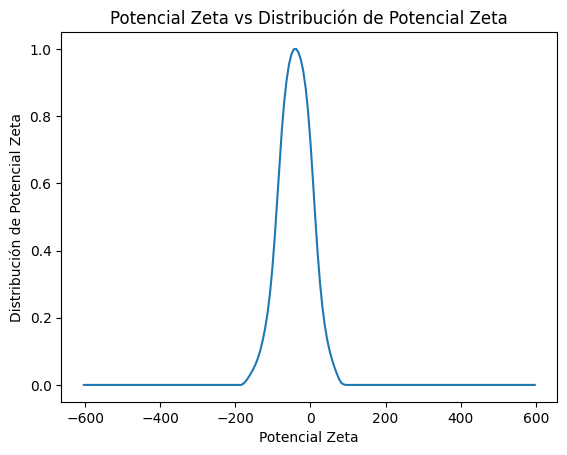

In [3]:
plt.plot(pZ,dPZ)
plt.xlabel('Potencial Zeta')
plt.ylabel('Distribución de Potencial Zeta')
plt.title('Potencial Zeta vs Distribución de Potencial Zeta')
plt.show()

Para resolver el problema, usaremos la función `minimize` contenida en `scipy.optimize`.

Definimos entonces nuestra función Gaussiana de la forma:

$$ f(x) = ae^{-\frac{(x-b)^2}{2c^2}} $$

 donde $ a $ es altura máxima de la curva, $ b $ es la posición del centro de la altura máxima de la curva, $ c $ es la desviación estándar y $ x $ sería nuestra variable independiente.

Además, definimos también el criterio de optimización y generamos un $ \beta_0 $ sabiendo que la amplitud máxima en una distribución es 1, la posición del centro de la altura máxima tal vez sea cercana al promedio y la desviación estándar es calculable directamente de los datos.

In [4]:
def funcGaussiana(x, a, b, c):
    return a * np.exp(-(x - b)**2 / (2 * c**2))

def criterio(beta, x, y):
    a, b, c = beta
    return np.sum((y - funcGaussiana(x, a, b, c))**2)

beta0 = [1, np.mean(pZ), np.std(pZ)]

Calculamos la solución con ayuda de la función minimize y extraemos las soluciones.

Para comprobar que efectivamente se hizo un ajuste lineal correcto, se generan valores en el rango de los valores medidos y se someten a la función ajustada para después graficarlos.

1.0382609909815845


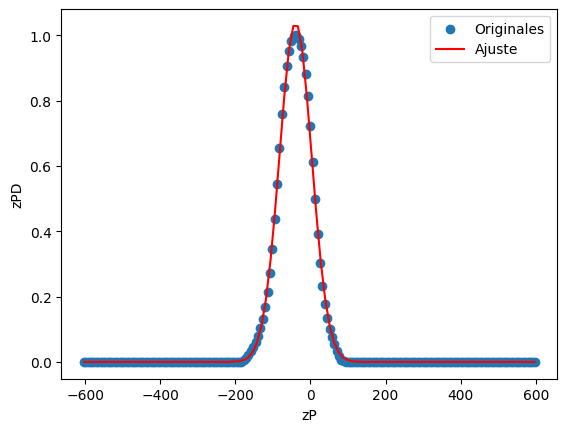

In [5]:
solucion = opt.minimize(criterio, beta0, args=(pZ, dPZ))

a, b, c = solucion.x

xAjustada = np.linspace(min(pZ), max(pZ), 100)
yAjustada = funcGaussiana(xAjustada, a, b, c)

print(funcGaussiana(-38, a, b, c))

plt.scatter(pZ, dPZ, label='Originales')
plt.plot(xAjustada, yAjustada, label='Ajuste', color='red')
plt.xlabel('zP')
plt.ylabel('zPD')
plt.legend()
plt.show()

### Conclusión

Este modelo es útil para obtener de manera más precisa en qué parte de la distribución se encuentra un potencial zeta en específico